# 0.0 데이터셋 수집 — Normal AES (tiny-AES-c)

## 이 노트북의 위치

`[extra] SCALib` 는 **Normal AES** 와 **Masked AES** 두 타겟을 비교한다.
하드웨어가 필요한 수집 노트북은 타겟마다 하나씩이다.

| | |
|---|---|
| 타겟 | `tiny-AES-c` / Normal AES (tiny-AES-c) |
| 펌웨어 | `simpleserial_tiny-AES-c/` |
| 출력 | `traces/scalib_dataset_tiny-AES-c.h5` |
| 마스크 `i_m` | 없음 (Normal) |
| 형제 노트북 | `0.1.Dataset_Collect_masked-aes-c.ipynb` |

수집 로직(연결·캡처·HDF5)은 `dataset_collect_lib.py` 한곳에 있다.
장수·시드는 `scalib_common.py` 와 공유하므로 두 타겟 입력 벡터가 정렬된다.

## 수집 Subset

| Subset | 키 | 평문 | 장수 |
|------|----|------|------|
| `/explore` | 랜덤 | 랜덤 | 5,000 |
| `/profiling` | 랜덤 | 랜덤 | 100,000 |
| `/attack` | **고정** | 랜덤 | 10,000 |
| `/tvla_rk` | 랜덤 | 고정 | 1,000 |
| `/tvla_fk` | **고정** | 고정 | 1,000 |

## 측정

| 항목 | 값 |
|------|----|
| 파형 길이 | `trig_count` 실측 (상수 금지) |
| `adc_mul` | 4 |
| `gain.db` | 25 |



## 배선 전제

```text
호스트 PC
  ├─ USB ─ ChipWhisperer-Lite  ──20pin── CW308 (UART, HS2 클럭, 프로그래밍)
  └─ USB ─ ChipWhisperer-Husky
              ├─ USERIO D0  ←  CW308 TRIG (GPIO4)
              ├─ AUX MCX    ←  CW308 CLKIN (클럭 분기)
              └─ Measure    ←  CW308 SHUNTL
```


---
## 1. 라이브러리와 상수

장수·시드는 `scalib_common` 정의. 줄이려면 그 파일을 고친다(두 수집이 같이 바뀜).


In [1]:
import time
import random
from pathlib import Path

import numpy as np
import h5py
import matplotlib
import matplotlib.pyplot as plt

import chipwhisperer as cw

from scalib_common import (
    TARGETS, SEED, N_EXPLORE, N_PROFILING, N_ATTACK, N_TVLA, AES_BLOCK, MASK_LEN,
)
from dataset_collect_lib import (
    my_fsr_cmd, aes_ecb_encrypt, target_aes_encrypt, target_get_masks,
    connect_all_devices, build_firmware, flash_firmware, setup_husky,
    measure_trig_count, apply_trig_count, capture_one, to_adc_code,
    Bench, run_full_collect, run_resume, GROUP_TARGETS,
)

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

TARGET_ID = "tiny-AES-c"
SPEC = TARGETS[TARGET_ID]
PLATFORM = "CW308_STM32F3"
CRYPTO_TARGET = "NONE"
SS_VER = "SS_VER_2_1"
ADC_MUL = 4
GAIN_DB = 25
WITH_MASKS = False

NB_DIR = Path.cwd()
SS_DIR = NB_DIR / "simpleserial_tiny-AES-c"
HEX_PATH = SS_DIR / ("simpleserial-base-%s.hex" % PLATFORM)
OUT_PATH = SPEC["dataset"]
CIPHER_ATTR = SPEC["cipher_attr"]

print("타겟   :", TARGET_ID, "/", SPEC["label"])
print("펌웨어 :", HEX_PATH)
print("출력   :", OUT_PATH)
print("마스크 :", WITH_MASKS)
print("규모   : explore %d / profiling %d / attack %d / tvla %d+%d"
      % (N_EXPLORE, N_PROFILING, N_ATTACK, N_TVLA, N_TVLA))
print("SEED   :", SEED)

/usr/local/lib/python3.12/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


타겟   : tiny-AES-c / Normal AES (tiny-AES-c)
펌웨어 : /workspace/[extra] SCALib/simpleserial_tiny-AES-c/simpleserial-base-CW308_STM32F3.hex
출력   : /workspace/[extra] SCALib/traces/scalib_dataset_tiny-AES-c.h5
마스크 : False
규모   : explore 5000 / profiling 100000 / attack 10000 / tvla 1000+1000
SEED   : 1234


---
## 2. 프로토콜

| cmd | scmd | 의미 |
|-----|------|------|
| `0x81` | `'k'`/`'p'`/`'l'` | 키 / 평문 / 길이 |
| `0x82` | `'c'` | `trigger_high` → `MY_AES_ECB` → `trigger_low` |
| `0x83` | `'r'` | 암호문 16B |


펌웨어: `simpleserial_tiny-AES-c/simpleserial-base.c`


---
## 3. Lite + Husky 연결


In [2]:
scopes = connect_all_devices()
lite_scope = scopes["ChipWhisperer_Lite"]
husky_scope = scopes["ChipWhisperer_Husky"]
if SS_VER != "SS_VER_2_1":
    raise OSError("SS_VER_2_1 만 지원한다.")
target = cw.target(lite_scope, cw.targets.SimpleSerial2)
print("[OK] Lite 에 SimpleSerial2 타겟 연결")

발견된 장치 수: 2


  [OK] ChipWhisperer_Husky  (SN: 502032204c5846303130313137313032 )
  [OK] ChipWhisperer_Lite  (SN: 44203120394d36433130322030313035 )
[OK] Lite 에 SimpleSerial2 타겟 연결


---
## 4. 펌웨어 빌드·플래시

`simpleserial_tiny-AES-c` → `../tiny-AES-c`.


In [3]:
build_firmware(SS_DIR, PLATFORM, CRYPTO_TARGET, SS_VER, HEX_PATH)
flash_firmware(lite_scope, PLATFORM, HEX_PATH)

빌드: make PLATFORM=CW308_STM32F3 CRYPTO_TARGET=NONE SS_VER=SS_VER_2_1 cwd= /workspace/[extra] SCALib/simpleserial_tiny-AES-c


[OK] 빌드 완료: /workspace/[extra] SCALib/simpleserial_tiny-AES-c/simpleserial-base-CW308_STM32F3.hex


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 3064219194                to 3075824062               
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538471                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538471.0               
scope.clock.clkgen_

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 6535 bytes at 0x8000000
STM32F Programming flash...


STM32F Reading flash...


Verified flash OK, 6535 bytes
[OK] 플래시 완료


---
## 5. 골든 AES 검증

호스트 `Crypto.Cipher.AES` 와 타겟 암호문이 같아야 한다.


In [4]:
random.seed(0)
k_test = bytearray(random.randint(0, 255) for _ in range(AES_BLOCK))
p_test = bytearray(random.randint(0, 255) for _ in range(AES_BLOCK))

ct_hw = target_aes_encrypt(target, k_test, p_test)
ct_sw = aes_ecb_encrypt(k_test, p_test)
print("key :", k_test.hex(" "))
print("pt  :", p_test.hex(" "))
print("HW  :", ct_hw.hex(" "))
print("SW  :", ct_sw.hex(" "))
if ct_hw != ct_sw:
    raise RuntimeError("골든 모델 불일치")
print("[OK] 골든 모델 일치")

if WITH_MASKS:
    m = target_get_masks(target)
    print("masks:", m.hex(" "), "len=", len(m))
    if len(m) != MASK_LEN:
        raise RuntimeError("마스크 길이 오류")
    # 두 번 암호화하면 마스크가 달라져야 한다(시드 후 rand 전진)
    target_aes_encrypt(target, k_test, p_test)
    m2 = target_get_masks(target)
    print("masks2:", m2.hex(" "))
    if m == m2:
        print("[주의] 연속 두 번 마스크가 같다 — srand/rand 경로를 의심한다.")
    else:
        print("[OK] 마스크가 암호화마다 변한다")

key : c5 d7 14 84 f8 cf 9b f4 b7 6f 47 90 47 30 80 4b
pt  : 9e 32 25 a9 f1 33 b5 de a1 68 f4 e2 85 1f 07 2f
HW  : 82 88 0a bc c8 46 0c e3 26 0b 26 69 60 21 6f 08
SW  : 82 88 0a bc c8 46 0c e3 26 0b 26 69 60 21 6f 08
[OK] 골든 모델 일치


---
## 6. Husky 설정 · `trig_count` 로 파형 길이

트리거는 `MY_AES_ECB` 전체를 감싼다. 길이는 상수로 정하지 않는다.


In [5]:
clk_hz = setup_husky(husky_scope, ADC_MUL, GAIN_DB)

scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen                   
scope.glitch.phase_shift_steps           changed from 0                         to 4592                     
scope.trace.capture

aux_io_mcx   = high_z
clkgen_src   = extclk_aux_io


(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


외부 클럭 최빈값 ≈ 7384494 Hz


(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


adc_locked   = True  adc_freq = 29537976.0
clkgen_locked= True  clkgen_freq = 7384494.0
gain.db      = 25.091743119266056
[OK] Husky 측정 설정 완료 (samples 미정)


In [6]:
trig_counts = [measure_trig_count(target, husky_scope, k_test, p_test) for _ in range(5)]
TRIG_COUNT, NS = apply_trig_count(husky_scope, trig_counts, ADC_MUL)

# 여기까지의 연결·측정 설정을 Bench 에 넘긴다. 수집 중 사고가 나면 Bench 가 이 값으로
# 장비를 그대로 다시 세워 복구한다. 넘기지 않은 값은 복구할 수 없다.
bench = Bench(scopes, target, platform=PLATFORM, adc_mul=ADC_MUL, gain_db=GAIN_DB,
              trig_count=TRIG_COUNT, ns=NS, clk_hz=clk_hz, with_masks=WITH_MASKS)
print("[OK] Bench 준비 — 복구 한도: 재시도 %d회 → 재연결 %d회 → 펌웨어 재기록 %d회"
      % (Bench.RETRY_CAPTURE, Bench.RETRY_RECONNECT, Bench.RETRY_REFLASH))

trig_count 회차: [33172, 33172, 33172, 33172, 33172]
TRIG_COUNT = 33172  →  adc.samples = 33172  (≈ 8293 사이클 @ adc_mul=4)
[OK] Bench 준비 — 복구 한도: 재시도 3회 → 재연결 2회 → 펌웨어 재기록 1회


---
## 7. 실측 후 정지 ★

소수 장으로 장당 시간과 용량을 잰다. 본수집 전에 수치를 확인한다.


In [7]:
N_BENCH = 20
rng_bench = np.random.RandomState(SEED)
t0 = time.time()
peak = 0.0
last_masks = None
for _ in range(N_BENCH):
    k = bytearray(rng_bench.randint(0, 256, AES_BLOCK, dtype=np.uint8).tolist())
    p = bytearray(rng_bench.randint(0, 256, AES_BLOCK, dtype=np.uint8).tolist())
    if WITH_MASKS:
        w, _, last_masks = capture_one(target, husky_scope, k, p, with_masks=True)
    else:
        w, _ = capture_one(target, husky_scope, k, p, with_masks=False)
    peak = max(peak, float(np.max(np.abs(w))))
dt = (time.time() - t0) / N_BENCH
N_TOTAL = N_EXPLORE + N_PROFILING + N_ATTACK + 2 * N_TVLA
bytes_total = N_TOTAL * NS * 2 + N_TOTAL * 3 * AES_BLOCK
if WITH_MASKS:
    bytes_total += N_TOTAL * MASK_LEN

print("=" * 62)
print(" 실측 — 본 수집 전 확인")
print("=" * 62)
print("  파형 길이     : %d 샘플 (%.0f 사이클)" % (NS, NS / ADC_MUL))
print("  장당 시간     : %.1f ms  (%.1f tr/s)" % (dt * 1000, 1.0 / dt))
print("  진폭 최댓값   : %.4f" % peak)
print("  총 장수       : %d" % N_TOTAL)
print("  예상 시간     : %.1f 분" % (N_TOTAL * dt / 60.0))
print("  예상 용량     : %.2f GB" % (bytes_total / 1e9))
if last_masks is not None:
    print("  마지막 마스크 :", last_masks.hex(" "))
print("=" * 62)
print("문제 없으면 §8 의 RUN_FULL_COLLECT = True")

 실측 — 본 수집 전 확인
  파형 길이     : 33172 샘플 (8293 사이클)
  장당 시간     : 39.6 ms  (25.3 tr/s)
  진폭 최댓값   : 0.1819
  총 장수       : 117000
  예상 시간     : 77.1 분
  예상 용량     : 7.77 GB
문제 없으면 §8 의 RUN_FULL_COLLECT = True


---
## 8. 본 수집

`RUN_FULL_COLLECT = True` 로 바꾼 뒤에만 실행. 배치마다 HDF5 에 기록한다.

### 사고가 나면 스스로 복구한다

수십만 장을 몇 시간 받는 동안 USB 는 끊기고 Husky 는 먹통이 된다. 사람이 지켜보다
다시 눌러 줄 수 없으므로, `Bench.capture()` 가 아래 순서로 스스로 회복한다.

| 단계 | 하는 일 | 최대 |
|:----:|---------|:----:|
| 1 | 단순 재시도 | 3회 |
| 2 | 재연결 — 장비를 다시 열고 클럭·게인·`adc.samples` 복원 | 2회 |
| 3 | **Husky 펌웨어 재기록** — 소거 후 다시 기록 | 1회 |

각 단계가 성공하면 그 자리에서 수집을 이어간다.

3단계가 필요한 이유는 실제로 겪었기 때문이다. Husky 펌웨어가 손상되면 버전은 정상값으로
보고하면서 `cw.scope()` 만 `Unknown hwInfoVer` 로 실패하는데, 이 고장은 USB 전원 차단이나
물리적 재삽입으로 낫지 않고 재기록만 듣는다. 실패해도 벽돌이 되지 않는다 — SAM 의
하드웨어 부트로더는 지울 수 없어 재시도할 수 있다.

전부 실패하면 예외를 올려 멈춘다. **이미 저장된 Subset 은 유효하므로** §8.1 이어받기로 재개한다.
몇 번 어떻게 살아났는지는 h5 의 `recoveries` attr 에 남는다 — 복구가 잦으면 배선을 손봐야 한다.

In [8]:
RUN_FULL_COLLECT = False  # ← §7 확인 후 True

if not RUN_FULL_COLLECT:
    print("RUN_FULL_COLLECT = False — 건너뛴다.")
else:
    run_full_collect(OUT_PATH, bench, CIPHER_ATTR)

RUN_FULL_COLLECT = False — 건너뛴다.


---
## 8.1 이어받기

자동 복구까지 실패해 §8 이 멈췄을 때 쓴다. 모자란 Subset 만 같은 시드 수열로 채우므로
입력 벡터가 어긋나지 않는다. 여기서도 같은 복구 사다리가 동작한다.

In [9]:
RUN_RESUME = False  # ← 이어받을 때 True

if not RUN_RESUME:
    if OUT_PATH.is_file():
        with h5py.File(OUT_PATH, "r") as h5:
            print("현재 상태")
            for name, need in GROUP_TARGETS.items():
                have = h5[name]["trace"].shape[0] if name in h5 else 0
                print("  /%-10s %7d / %7d  %s" % (
                    name, have, need, "OK" if have >= need else "부족"))
            rec = list(h5.attrs.get("recoveries", []))
            if rec:
                print("자동 복구 이력:", [r.decode() for r in rec])
    else:
        print("데이터셋 없음 — §8 먼저.")
else:
    run_resume(OUT_PATH, bench)

현재 상태
  /explore       5000 /    5000  OK
  /attack       10000 /   10000  OK
  /tvla_rk       1000 /    1000  OK
  /tvla_fk       1000 /    1000  OK
  /profiling   100000 /  100000  OK


---
## 9. 저장 결과 확인


=== attrs ===
  acquisition_start        2026-08-07T00:34:27
  alignment                none
  channel_gain_db          25.091743119266056
  channel_probe            CW308 SHUNTL (내장 션트), Husky Measure 입력
  channel_type             power
  fixed_key                [ 47 107   7  49 211 226 102 127  38 133  66 159  53 220  93 209]
  fixed_pt                 [204 236  14 112 116  93 179 156 152  66  13 201 249 215 119 197]
  iut_algorithm            AES-128-ECB
  iut_countermeasure       none
  iut_implementation       tiny-AES-c
  rng_seed                 1234
  sample_dtype             int16
  sample_rate_hz           29537976.0
  sample_resolution_bits   12
  sample_scale             32768.0
  samples_per_trace        33172
  schema                   sca-hdf5
  schema_version           1.0
  synchronous_sampling     True
  target_clock_hz          7384494.0
  target_device            STM32F303
  target_name              CW308_STM32F3
  tool_chain               chipwhisperer 6.0.0; pyth

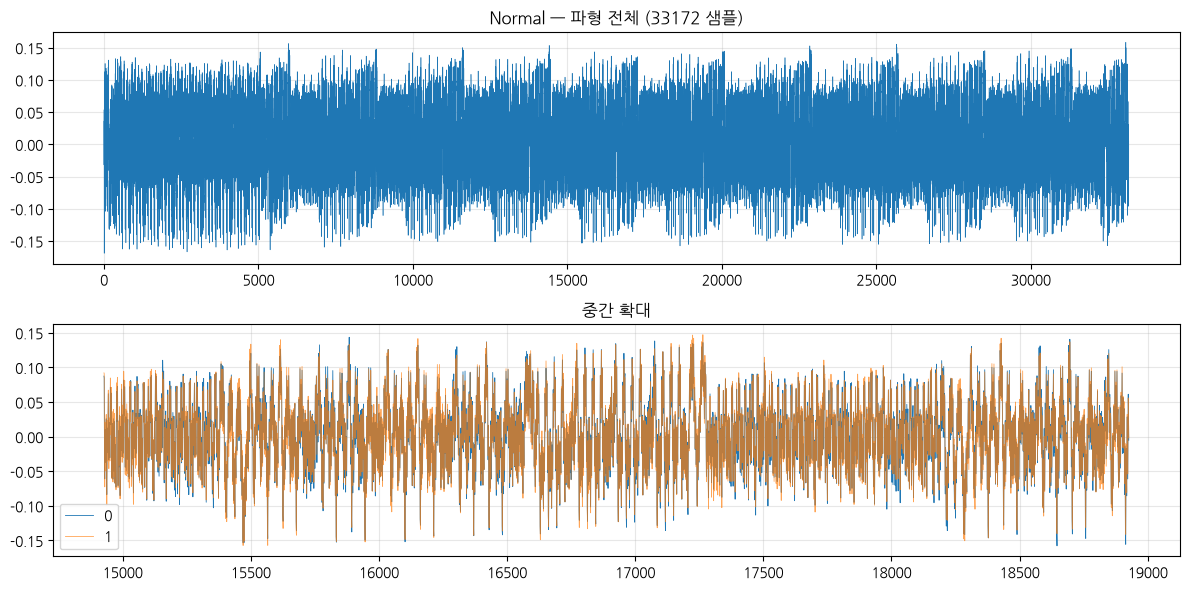

In [10]:
if not OUT_PATH.is_file():
    print("데이터셋이 없다.")
else:
    with h5py.File(OUT_PATH, "r") as h5:
        print("=== attrs ===")
        for k in sorted(h5.attrs):
            print("  %-24s %s" % (k, h5.attrs[k]))
        print("=== Subset ===")
        for name in h5:
            g = h5[name]
            extra = (" mask%s" % (g["mask"].shape,)) if "mask" in g else ""
            print("  /%-10s [%s] trace%s%s"
                  % (name, g.attrs.get("role", "?"), g["trace"].shape, extra))
        ns = int(h5.attrs["samples_per_trace"])
        scale = float(h5.attrs["sample_scale"])
        w0 = h5["explore/trace"][0].astype(np.float64) / scale
        w1 = h5["explore/trace"][1].astype(np.float64) / scale
        if "mask" in h5["explore"]:
            print("explore mask[0]:", bytes(h5["explore/mask"][0]).hex(" "))

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    axes[0].plot(w0, lw=0.4)
    axes[0].set_title("%s — 파형 전체 (%d 샘플)" % (SPEC["short"], ns))
    s0 = int(ns * 0.45)
    nshow = min(4000, ns - s0)
    axes[1].plot(range(s0, s0 + nshow), w0[s0:s0 + nshow], lw=0.6, label="0")
    axes[1].plot(range(s0, s0 + nshow), w1[s0:s0 + nshow], lw=0.6, alpha=0.7, label="1")
    axes[1].legend(); axes[1].set_title("중간 확대")
    for ax in axes:
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

---
## 10. 자원 해제


In [11]:
bench.disconnect()
print("완료.")

[OK] target.dis()
[OK] ChipWhisperer_Husky.dis()
[OK] ChipWhisperer_Lite.dis()
완료.


---
## 11. 요약

| 항목 | 내용 |
|------|------|
| 타겟 | Normal AES (tiny-AES-c) |
| 트리거 | `MY_AES_ECB` 전체 |
| 저장 | `traces/scalib_dataset_tiny-AES-c.h5` |
| 마스크 | 없음 |

다음: 형제 타겟 수집 후 `1.0.SNR.ipynb` 에서 두 타겟을 단계별로 비교한다.
